In [100]:
import numpy as np
import torch 
import torch.nn as nn 
import matplotlib.pyplot as plt 
from IPython import display

<function matplotlib.pyplot.show(close=None, block=None)>

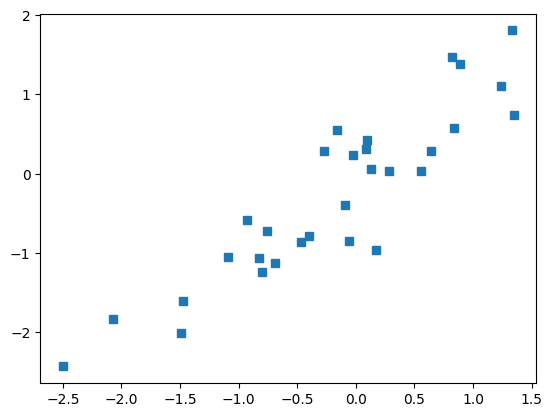

In [101]:
N=30
x=torch.randn(N,1)
y=x+torch.randn(N,1)/2
plt.plot(x,y,'s')
plt.show


In [102]:
ANNreg = nn.Sequential(
    nn.Linear(1,1),
    nn.ReLU(),
    nn.Linear(1,1)
)

ANNreg

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)

In [103]:
learningRate = 0.05

lossfun = nn.MSELoss()

optimizer=torch.optim.SGD(ANNreg.parameters(),lr=learningRate)

In [104]:
numepochs=500
losses=torch.zeros(numepochs)
high_loss_count = 0
final_losses = []

for i in range(100):
    # Create fresh model instance each iteration
    ANNreg = nn.Sequential(
        nn.Linear(1,1),
        nn.ReLU(),
        nn.Linear(1,1)
    )
    
    learningRate = 0.05
    lossfun = nn.MSELoss()
    optimizer = torch.optim.SGD(ANNreg.parameters(),lr=learningRate)
    
    for epochi in range(numepochs):
        yHat=ANNreg(x)

        loss=lossfun(yHat,y)
        losses[epochi]=loss 

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    final_losses.append(loss.item())
    if loss.item() > 0.25:
        high_loss_count += 1

high_loss_count

41

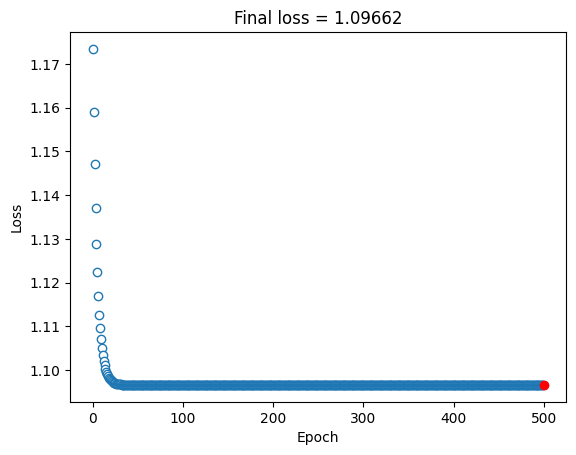

In [105]:
predictions=ANNreg(x)

testloss=(predictions-y).pow(2).mean()
plt.plot(losses.detach(),'o',markerfacecolor='w',linewidth=0.1)
plt.plot(numepochs,testloss.detach(),'ro')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final loss = %g' %testloss.item())
plt.show()

/home/user/Documents/LLMs-from-Scratch/llmsenv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/user/Documents/LLMs-from-Scratch/llmsenv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


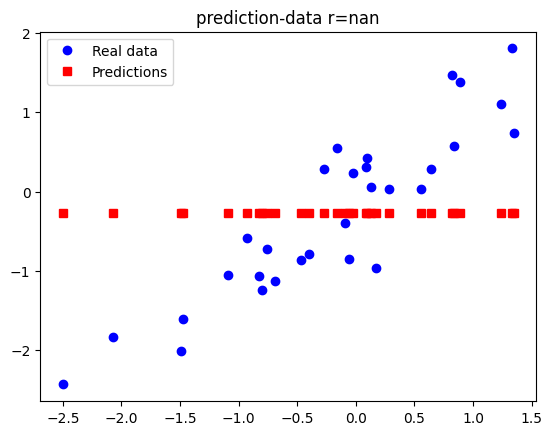

In [106]:
plt.plot(x,y,'bo',label='Real data')
plt.plot(x,predictions.detach(),'rs',label='Predictions')
plt.title(f'prediction-data r={np.corrcoef(y.T,predictions.detach().T)[0,1]:.2f}')
plt.legend()
plt.show()

In [107]:
print(f"Number of runs with loss > 0.25: {high_loss_count} out of 100")
print(f"Percentage of failures: {100 * high_loss_count / 100:.1f}%")
print(f"Mean final loss: {np.mean(final_losses):.4f}")
print(f"Std of final loss: {np.std(final_losses):.4f}")

Number of runs with loss > 0.25: 41 out of 100
Percentage of failures: 41.0%
Mean final loss: 0.5647
Std of final loss: 0.4434
